In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
data = pd.read_csv(r"C:\Users\divya\OneDrive\Documents\Experiments\Exp-10\ratings.csv")

data.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [10]:
user_item_matrix = data.pivot(index='userId',
                             columns='movieId',
                             values='rating')

# Fill missing values
matrix_filled = user_item_matrix.fillna(0)

print("Matrix Shape:", matrix_filled.shape)
matrix_filled.head()

Matrix Shape: (610, 9724)


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
# Mean centering
user_mean = matrix_filled.mean(axis=1)
matrix_norm = matrix_filled.sub(user_mean, axis=0)

matrix_norm.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,3.895825,-0.104175,3.895825,-0.104175,-0.104175,3.895825,-0.104175,-0.104175,-0.104175,-0.104175,...,-0.104175,-0.104175,-0.104175,-0.104175,-0.104175,-0.104175,-0.104175,-0.104175,-0.104175,-0.104175
2,-0.011775,-0.011775,-0.011775,-0.011775,-0.011775,-0.011775,-0.011775,-0.011775,-0.011775,-0.011775,...,-0.011775,-0.011775,-0.011775,-0.011775,-0.011775,-0.011775,-0.011775,-0.011775,-0.011775,-0.011775
3,-0.009770,-0.009770,-0.009770,-0.009770,-0.009770,-0.009770,-0.009770,-0.009770,-0.009770,-0.009770,...,-0.009770,-0.009770,-0.009770,-0.009770,-0.009770,-0.009770,-0.009770,-0.009770,-0.009770,-0.009770
4,-0.078980,-0.078980,-0.078980,-0.078980,-0.078980,-0.078980,-0.078980,-0.078980,-0.078980,-0.078980,...,-0.078980,-0.078980,-0.078980,-0.078980,-0.078980,-0.078980,-0.078980,-0.078980,-0.078980,-0.078980
5,3.983546,-0.016454,-0.016454,-0.016454,-0.016454,-0.016454,-0.016454,-0.016454,-0.016454,-0.016454,...,-0.016454,-0.016454,-0.016454,-0.016454,-0.016454,-0.016454,-0.016454,-0.016454,-0.016454,-0.016454


In [12]:
k = 20  # latent factors

svd = TruncatedSVD(n_components=k, random_state=42)

U = svd.fit_transform(matrix_norm)
Sigma = np.diag(svd.singular_values_)
VT = svd.components_

In [13]:
svd_reconstructed = np.dot(np.dot(U, Sigma), VT)

# Add mean back
svd_reconstructed = svd_reconstructed + user_mean.values.reshape(-1, 1)

svd_reconstructed[:5, :5]

array([[1122.95159011,  538.89233014,  304.44831635,  -53.87055005,
         101.4738357 ],
       [  71.7315285 ,   36.90887571,   -3.53653788,   -6.30920251,
           1.26754616],
       [   7.77001743,    6.50344997,    5.45893262,   -1.44776909,
          -5.18885316],
       [ 700.89159287,  176.96632513,   96.09202697,  -21.13847408,
          70.60317985],
       [ 386.78696969,  239.9385396 ,   97.58347486,   12.06947675,
         104.30534544]])

In [15]:
rmse_svd = np.sqrt(mean_squared_error(matrix_filled, svd_reconstructed))
mae_svd = mean_absolute_error(matrix_filled, svd_reconstructed)

print("SVD RMSE:", rmse_svd)
print("SVD MAE :", mae_svd)

SVD RMSE: 98.77847729892088
SVD MAE : 37.502956981909655


In [16]:
def recommend_svd(user_id, n=5):
    user_ratings = svd_reconstructed[user_id - 1]
    top_items = np.argsort(user_ratings)[-n:][::-1]
    return top_items

print("Top 5 Recommendations for User 1:")
print(recommend_svd(1))

Top 5 Recommendations for User 1:
[ 224  897 1938  257  910]


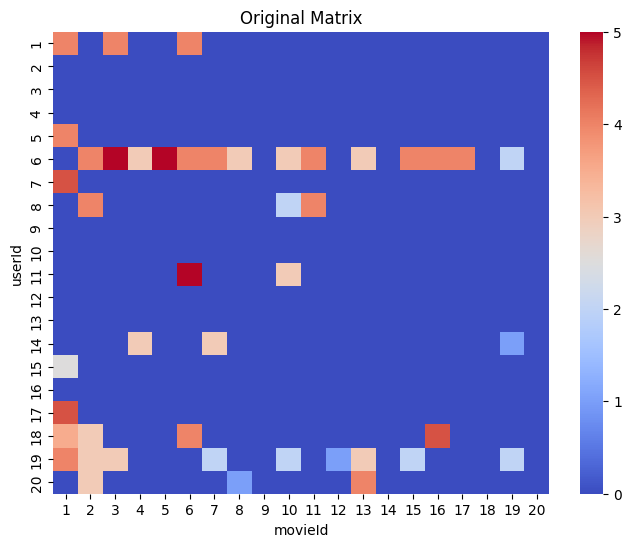

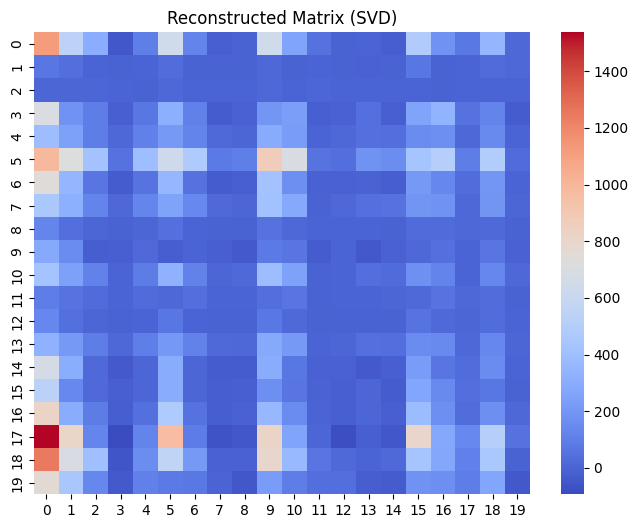

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(matrix_filled.iloc[:20, :20], cmap="coolwarm")
plt.title("Original Matrix")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(svd_reconstructed[:20, :20], cmap="coolwarm")
plt.title("Reconstructed Matrix (SVD)")
plt.show()

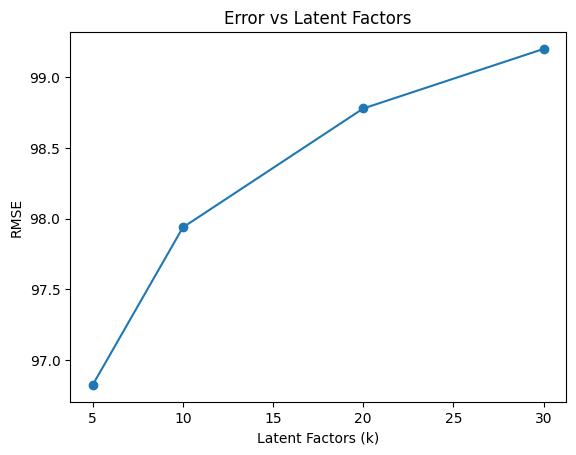

In [18]:
k_values = [5, 10, 20, 30]
rmse_list = []

for k in k_values:
    svd_temp = TruncatedSVD(n_components=k, random_state=42)
    U_temp = svd_temp.fit_transform(matrix_norm)
    Sigma_temp = np.diag(svd_temp.singular_values_)
    VT_temp = svd_temp.components_

    reconstructed = np.dot(np.dot(U_temp, Sigma_temp), VT_temp)
    reconstructed = reconstructed + user_mean.values.reshape(-1, 1)

    rmse = np.sqrt(mean_squared_error(matrix_filled, reconstructed))
    rmse_list.append(rmse)

plt.plot(k_values, rmse_list, marker='o')
plt.xlabel("Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("Error vs Latent Factors")
plt.show()

In [19]:
def precision_recall_at_k(actual, predicted, k=5):
    pred_k = predicted[:k]
    precision = len(set(pred_k) & set(actual)) / k
    recall = len(set(pred_k) & set(actual)) / len(actual)
    return precision, recall

# Example
actual_items = [1, 2, 3]
predicted_items = recommend_svd(1)

precision, recall = precision_recall_at_k(actual_items, predicted_items)

print("Precision:", precision)
print("Recall   :", recall)

Precision: 0.0
Recall   : 0.0
